<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/Emulator_Aug2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.flush_and_unmount()

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [1]:
from google.colab import drive
import os
def is_drive_mounted():
    return os.path.exists('/content/drive')
if not is_drive_mounted(): drive.mount('/content/drive')


Mounted at /content/drive


# Emulator with new architecture

In [6]:
# ============================================================
# train_resunet_1layer_big50_ai_emul2.py
# ------------------------------------------------------------
# Multiscale ResUNet trainer for 1-layer SWE emulator
# on Klein beta-plane, based on the previous ResCNN trainer.
#
# Keeps:
#   - big50 data, DT_MACRO = 50 * 30 s
#   - multistep rollout data loss
#   - multitime collocation losses
#   - continuity residual
#   - relative/scaled momentum residual
#   - weak geostrophic balance
#   - weak smoothness
#   - normalized UV magnitude loss
#   - normalized KE matching loss
#   - local KE-APE energy tendency consistency
#   - restart-safe checkpointing
#
# Main architecture change:
#   MultiStepContinuousResCNNModel
#       -> MultiStepContinuousResUNetModel
#
# Outputs go to:
#   /content/drive/MyDrive/AI_EMUL2/training_runs/...
# ============================================================

import os
import sys
import glob
import csv
import time
import random
import re
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Import CollocBank
# ------------------------------------------------------------
sys.path.append("/content/drive/MyDrive/AI_4DVAR")
from colloc_bank import CollocBank

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# USER CONFIG
# ------------------------------------------------------------
class CFG:
    # -------- paths --------
    ROOT_CODE = "/content/drive/MyDrive/AI_4DVAR"

    # Use AI_EMUL2 for outputs.  Data/collocation can be read from
    # AI_EMUL2 if copied there, otherwise the script falls back to AI_EMUL.
    ROOT_OUT = "/content/drive/MyDrive/AI_EMUL2"

    DATA_DIR_CANDIDATES = [
        "/content/drive/MyDrive/AI_EMUL2/klein_ckpt_1L_big50",
        "/content/drive/MyDrive/AI_EMUL/klein_ckpt_1L_big50",
    ]

    COLLOC_DIR_CANDIDATES = [
        "/content/drive/MyDrive/AI_EMUL2/klein_ml_1L_big50/colloc_raw",
        "/content/drive/MyDrive/AI_EMUL/klein_ml_1L_big50/colloc_raw",
    ]

    # EXP_NAME = "resunet_b96_big50_t8_energyex_momrel_lr5e5"
    # EXP_NAME = "resunet_b96_big50_t8_energyex_momrel_lr5e5_v2"
    EXP_NAME = "resunet_b96_big50_t8_energyex_uvgrad_momrel_lr5e5"


    # -------- domain / physics --------
    NX = 256
    NY = 128
    Lx = 2.0e7
    Ly = 8.0e6
    H = 1000.0
    G = 9.81
    DT_MACRO = 50.0 * 30.0
    FMIN = 2.0e-5

    # -------- normalization scales --------
    U_SCALE = 50.0
    KE_SCALE = 0.5 * U_SCALE**2
    ENERGY_TEND_SCALE = 1.0e-3

    # -------- architecture --------
    # BASE_CH=96 is closest to your previous c96 model.
    # If Colab memory is tight, set BASE_CH=64 first.
    BASE_CH = 96
    FEAT_CH = 96
    HIDDEN  = 192

    # ResUNet block counts per scale.
    ENC_BLOCKS = 2
    MID_BLOCKS = 4
    DEC_BLOCKS = 2

    # -------- optimization --------
    EPOCHS = 40
    BATCH_SIZE = 1
    LR = 5e-5
    WEIGHT_DECAY = 1e-6
    GRAD_CLIP = 1.0

    # -------- rollout --------
    ROLL_STEPS = 8
    ROLL_GAMMA = 0.95

    # -------- data loading --------
    MAX_WINDOWS_PER_IC = 12
    NUM_WORKERS = 0
    PIN_MEMORY = torch.cuda.is_available()

    # -------- collocation controls --------
    N_TIME_SLICES = 8
    PTS_PER_TIME  = 4

    # -------- loss weights --------
    LAMBDA_DATA        = 1.0
    LAMBDA_COLL_STATE  = 0.1
    LAMBDA_COLL_TEND   = 0.2
    LAMBDA_CONT        = 0.5
    LAMBDA_MOM         = 5.0
    LAMBDA_GEO         = 0.01
    LAMBDA_SMOOTH      = 1e-2

    # These are intentionally weak and normalized.
    LAMBDA_UV_MAG      = 2e-6
    LAMBDA_KE          = 2e-4
    LAMBDA_ENERGY_TEND = 0.05
    LAMBDA_UV_GRAD = 0.01

    # -------- safety clamp during recursive training --------
    USE_STATE_CLAMP = True
    ETA_CLAMP = 2000.0
    UV_CLAMP  = 150.0

    # -------- misc / restart --------
    SAVE_EVERY_EPOCH = 1
    PRINT_BATCH_EVERY = 25
    AUTO_RESUME = True
    RESUME_FROM = None
    MAX_BATCHES_PER_EPOCH = None

cfg = CFG()

cfg.DX = cfg.Lx / cfg.NX
cfg.DY = cfg.Ly / cfg.NY
cfg.CKPT_DIR = os.path.join(cfg.ROOT_OUT, "training_runs", cfg.EXP_NAME)
os.makedirs(cfg.CKPT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def count_pairs_in_root(data_dir):
    if not os.path.exists(data_dir):
        return 0, 0
    ic_dirs = [d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)]
    n_ic = 0
    n_pairs = 0
    for ic_dir in ic_dirs:
        files = sorted(glob.glob(os.path.join(ic_dir, "klein_step_*.npz")))
        if len(files) >= 2:
            n_ic += 1
            n_pairs += (len(files) - 1)
    return n_ic, n_pairs

def autodetect_data_dir(candidates):
    print("[AutoDetect] checking candidate snapshot roots...")
    best_dir = None
    best_pairs = -1
    for d in candidates:
        n_ic, n_pairs = count_pairs_in_root(d)
        print(f"  {d}")
        print(f"     valid IC dirs = {n_ic}, total pairs = {n_pairs}")
        if n_pairs > best_pairs:
            best_pairs = n_pairs
            best_dir = d
    if best_dir is None or best_pairs <= 0:
        raise RuntimeError("No valid snapshot root found. Check DATA_DIR_CANDIDATES.")
    print(f"[AutoDetect] using data: {best_dir}")
    return best_dir

def autodetect_existing_dir(candidates, label="directory"):
    print(f"[AutoDetect] checking candidate {label}s...")
    for d in candidates:
        print(f"  {d} -> exists={os.path.exists(d)}")
        if os.path.exists(d):
            print(f"[AutoDetect] using {label}: {d}")
            return d
    raise RuntimeError(f"No valid {label} found from candidates.")

_step_re = re.compile(r"klein_step_(\d+)\.npz")

def extract_step_from_path(path):
    m = _step_re.search(os.path.basename(path))
    if m is None:
        raise ValueError(f"Could not parse step from {path}")
    return int(m.group(1))

def save_checkpoint(path, model, optimizer, epoch, loss_history, data_dir, colloc_dir):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "data_dir": data_dir,
            "colloc_dir": colloc_dir,
            "exp_name": cfg.EXP_NAME,
            "model_class": "MultiStepContinuousResUNetModel",
            "config": {k: v for k, v in cfg.__dict__.items() if not k.startswith("__")},
        },
        path,
    )

def load_checkpoint(path, model, optimizer=None):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return ckpt.get("epoch", -1), ckpt.get("loss_history", []), ckpt

def save_loss_csv(path, loss_history):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([
            "epoch", "train_total", "train_data",
            "train_coll_state", "train_coll_tend",
            "train_cont", "train_mom",
            "train_geo", "train_smooth",
            "train_uv_mag", "train_ke", "train_energy_tend",
        ])
        for row in loss_history:
            w.writerow(row)
def clamp_state(x):
    if not cfg.USE_STATE_CLAMP:
        return x

    eta = torch.clamp(x[:, 0:1], -cfg.ETA_CLAMP, cfg.ETA_CLAMP)
    u   = torch.clamp(x[:, 1:2], -cfg.UV_CLAMP,  cfg.UV_CLAMP)
    v   = torch.clamp(x[:, 2:3], -cfg.UV_CLAMP,  cfg.UV_CLAMP)

    return torch.cat([eta, u, v], dim=1)

def grid_uv_grad_loss(x):
    """
    x shape: [B, 3, NY, NX]
    channels: eta, u, v
    """
    u = x[:, 1:2]
    v = x[:, 2:3]

    du_dx = u[:, :, :, 1:] - u[:, :, :, :-1]
    du_dy = u[:, :, 1:, :] - u[:, :, :-1, :]

    dv_dx = v[:, :, :, 1:] - v[:, :, :, :-1]
    dv_dy = v[:, :, 1:, :] - v[:, :, :-1, :]

    return (
        (du_dx**2).mean()
        + (du_dy**2).mean()
        + (dv_dx**2).mean()
        + (dv_dy**2).mean()
    )


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------
class SWWindowDataset(Dataset):
    def __init__(self, data_dir, roll_steps=4, max_windows_per_ic=None):
        self.samples = []

        ic_dirs = sorted([d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)])
        print(f"[Dataset] found {len(ic_dirs)} IC directories")

        for ic_dir in ic_dirs:
            ic_key = os.path.basename(ic_dir)
            files = sorted(glob.glob(os.path.join(ic_dir, "klein_step_*.npz")), key=extract_step_from_path)
            print(f"[Dataset] {ic_key:20s} -> {len(files)} snapshot files")

            if len(files) < (roll_steps + 1):
                continue

            windows = []
            for i in range(len(files) - roll_steps):
                fseq = files[i:i + roll_steps + 1]
                macro_start_index = i + 1
                windows.append((fseq, ic_key, macro_start_index))

            if max_windows_per_ic is not None:
                windows = windows[:max_windows_per_ic]

            self.samples.extend(windows)

        if len(self.samples) == 0:
            raise RuntimeError("No usable training windows found.")

        print(f"[Dataset] total windows = {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fseq, ic_key, macro_start_index = self.samples[idx]

        seq = []
        times = []
        steps = []

        for f in fseq:
            z = np.load(f)
            seq.append(np.stack([z["eta"], z["uc"], z["vc"]], axis=0).astype(np.float32))
            times.append(float(z["t"]))
            steps.append(int(extract_step_from_path(f)))

        seq = np.stack(seq, axis=0)

        return {
            "seq": torch.from_numpy(seq),
            "times": np.array(times, dtype=np.float32),
            "steps": np.array(steps, dtype=np.int32),
            "ic_key": ic_key,
            "macro_start_index": np.int32(macro_start_index),
        }

# ------------------------------------------------------------
# Model: ResUNet multiscale emulator
# ------------------------------------------------------------
class ResBlock(nn.Module):
    def __init__(self, ch, dilation=1):
        super().__init__()
        pad = dilation
        self.c1 = nn.Conv2d(ch, ch, 3, padding=pad, dilation=dilation)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=pad, dilation=dilation)
        self.act = nn.GELU()

    def forward(self, x):
        r = x
        x = self.act(self.c1(x))
        x = self.c2(x)
        return self.act(x + r)

class ResStack(nn.Module):
    def __init__(self, ch, n_blocks=2, dilations=(1, 2)):
        super().__init__()
        blocks = []
        for i in range(n_blocks):
            blocks.append(ResBlock(ch, dilation=dilations[i % len(dilations)]))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks=2):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
            nn.GELU(),
        )
        self.res = ResStack(out_ch, n_blocks=n_blocks, dilations=(1, 2))

    def forward(self, x):
        x = self.down(x)
        return self.res(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_blocks=2):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.GELU(),
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.res = ResStack(out_ch, n_blocks=n_blocks, dilations=(1, 2))

    def forward(self, x, skip):
        x = self.up(x)

        # Safety for odd sizes, although 128x256 is divisible by 4.
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        x = torch.cat([x, skip], dim=1)
        x = self.fuse(x)
        return self.res(x)

class MultiStepContinuousResUNetModel(nn.Module):
    """
    Multiscale ResUNet with the same public interface as the previous model:

      feat = model.encode(x)
      xdot = model.grid_tendency(feat)
      state_hat = model.query_state(x_1b, feat_1b, x_norm, y_norm, tau)

    This keeps the collocation/physics code unchanged.
    """
    def __init__(self, in_ch=3, base_ch=96, feat_ch=96, hidden=192,
                 enc_blocks=2, mid_blocks=4, dec_blocks=2):
        super().__init__()
        c0 = base_ch
        c1 = base_ch * 2
        c2 = base_ch * 4

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, c0, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(c0, c0, 3, padding=1),
            nn.GELU(),
        )

        self.enc0 = ResStack(c0, n_blocks=enc_blocks, dilations=(1, 2))
        self.down1 = DownBlock(c0, c1, n_blocks=enc_blocks)
        self.down2 = DownBlock(c1, c2, n_blocks=enc_blocks)

        self.mid = ResStack(c2, n_blocks=mid_blocks, dilations=(1, 2, 4, 2))

        self.up1 = UpBlock(c2, c1, c1, n_blocks=dec_blocks)
        self.up0 = UpBlock(c1, c0, c0, n_blocks=dec_blocks)

        # Project final multiscale feature to feat_ch so query_mlp input stays controlled.
        self.feat_proj = nn.Sequential(
            nn.Conv2d(c0, feat_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(feat_ch, feat_ch, 3, padding=1),
            nn.GELU(),
        )

        self.grid_head = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(feat_ch, 3, 3, padding=1),
        )

        self.query_mlp = nn.Sequential(
            nn.Linear(feat_ch + 3 + 3, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 3),
        )

        # zero-init safe start
        nn.init.zeros_(self.grid_head[-1].weight)
        nn.init.zeros_(self.grid_head[-1].bias)
        nn.init.zeros_(self.query_mlp[-1].weight)
        nn.init.zeros_(self.query_mlp[-1].bias)

    def encode(self, x):
        s0 = self.stem(x)
        e0 = self.enc0(s0)
        e1 = self.down1(e0)
        e2 = self.down2(e1)
        m  = self.mid(e2)
        d1 = self.up1(m, e1)
        d0 = self.up0(d1, e0)
        feat = self.feat_proj(d0)
        return feat

    def grid_tendency(self, feat):
        return self.grid_head(feat)

    def _sample_local(self, field_1b, x_norm_detached, y_norm_detached):
        grid = torch.stack([x_norm_detached, y_norm_detached], dim=-1).view(1, -1, 1, 2)
        vals = F.grid_sample(
            field_1b, grid,
            mode="bilinear",
            padding_mode="border",
            align_corners=True,
        )
        return vals.squeeze(0).squeeze(-1).transpose(0, 1)

    def query_state(self, x_1b, feat_1b, x_norm, y_norm, tau):
        x_norm_s = x_norm.detach()
        y_norm_s = y_norm.detach()

        feat_local = self._sample_local(feat_1b, x_norm_s, y_norm_s)
        state0_local = self._sample_local(x_1b, x_norm_s, y_norm_s)

        q = torch.stack([x_norm, y_norm, tau], dim=-1)
        inp = torch.cat([feat_local, state0_local, q], dim=-1)

        delta = self.query_mlp(inp)
        return state0_local + tau.unsqueeze(-1) * delta

# ------------------------------------------------------------
# Collocation sampling
# ------------------------------------------------------------
def sample_multitime_colloc(colloc_bank, ic_key, macro_index, n_time_slices=4, pts_per_time=4):
    n_request = max(n_time_slices * pts_per_time * 8, 64)
    base = colloc_bank.sample_nearest_macro(
        ic_key=ic_key,
        macro_index=macro_index,
        npts=n_request,
        replace=True,
    )

    t_sec = np.asarray(base["t_sec"]).reshape(-1)
    if t_sec.size == 0:
        return base

    order = np.argsort(t_sec)
    bins = np.array_split(order, n_time_slices)

    chosen = []
    for b in bins:
        if len(b) == 0:
            continue
        take = min(pts_per_time, len(b))
        idx = np.random.choice(b, size=take, replace=False)
        chosen.append(idx)

    if len(chosen) == 0:
        chosen = [order[:min(pts_per_time, len(order))]]

    chosen = np.concatenate(chosen, axis=0)

    out = {}
    for k, arr in base.items():
        arr = np.asarray(arr)
        if arr.ndim >= 1 and arr.shape[0] == len(t_sec):
            out[k] = arr[chosen]
        else:
            out[k] = arr
    return out

# ------------------------------------------------------------
# Derivative / balance helpers
# ------------------------------------------------------------
def safe_coriolis_torch(f, fmin):
    sign = torch.sign(f)
    sign = torch.where(sign == 0.0, torch.ones_like(sign), sign)
    return sign * torch.clamp(torch.abs(f), min=fmin)

# ------------------------------------------------------------
# Collocation losses
# ------------------------------------------------------------
def continuous_interval_losses_multitime(model, x_1b, feat_1b, colloc, t_start, dt_macro):
    x_m = torch.as_tensor(colloc["x_m"], dtype=torch.float32, device=device)
    y_m = torch.as_tensor(colloc["y_m"], dtype=torch.float32, device=device)
    t_sec = torch.as_tensor(colloc["t_sec"], dtype=torch.float32, device=device)

    tau = (t_sec - t_start) / dt_macro
    tau = torch.clamp(tau, 0.0, 1.0)

    x_norm = (2.0 * x_m / cfg.Lx) - 1.0
    y_norm = (2.0 * y_m / cfg.Ly) - 1.0

    x_norm = x_norm.clone().detach().requires_grad_(True)
    y_norm = y_norm.clone().detach().requires_grad_(True)
    tau    = tau.clone().detach().requires_grad_(True)

    state_hat = model.query_state(x_1b, feat_1b, x_norm, y_norm, tau)
    eta_hat = state_hat[:, 0]
    u_hat   = state_hat[:, 1]
    v_hat   = state_hat[:, 2]
    h_hat   = cfg.H + eta_hat

    # ------------------------------------------------------------
    # Velocity gradient regularization
    # ------------------------------------------------------------

    def grads_of(field):
        gx, gy, gt = torch.autograd.grad(
            field.sum(), [x_norm, y_norm, tau],
            create_graph=True, retain_graph=True
        )
        return gx, gy, gt

    eta_xn, eta_yn, eta_tau = grads_of(eta_hat)
    u_xn,   u_yn,   u_tau   = grads_of(u_hat)
    v_xn,   v_yn,   v_tau   = grads_of(v_hat)

    eta_x = eta_xn * (2.0 / cfg.Lx)
    eta_y = eta_yn * (2.0 / cfg.Ly)
    h_x = eta_x
    h_y = eta_y

    u_x = u_xn * (2.0 / cfg.Lx)
    u_y = u_yn * (2.0 / cfg.Ly)
    v_x = v_xn * (2.0 / cfg.Lx)
    v_y = v_yn * (2.0 / cfg.Ly)

    eta_t = eta_tau / dt_macro
    h_t = eta_t
    u_t = u_tau / dt_macro
    v_t = v_tau / dt_macro

    hu = h_hat * u_hat
    hv = h_hat * v_hat
    hu_xn, _, _ = grads_of(hu)
    _, hv_yn, _ = grads_of(hv)
    hu_x = hu_xn * (2.0 / cfg.Lx)
    hv_y = hv_yn * (2.0 / cfg.Ly)

    eta_true = torch.as_tensor(colloc["eta"], dtype=torch.float32, device=device)
    u_true   = torch.as_tensor(colloc["uc"],  dtype=torch.float32, device=device)
    v_true   = torch.as_tensor(colloc["vc"],  dtype=torch.float32, device=device)

    deta_dt_fd = torch.as_tensor(colloc["deta_dt_fd"], dtype=torch.float32, device=device)
    duc_dt_fd  = torch.as_tensor(colloc["duc_dt_fd"],  dtype=torch.float32, device=device)
    dvc_dt_fd  = torch.as_tensor(colloc["dvc_dt_fd"],  dtype=torch.float32, device=device)

    f_fd = torch.as_tensor(colloc["f"], dtype=torch.float32, device=device)

    # ------------------------------------------------------------
    # Local KE-APE energy tendency consistency
    # ------------------------------------------------------------
    ke_t_hat = u_hat * u_t + v_hat * v_t
    ape_t_hat = (cfg.G / cfg.H) * eta_hat * eta_t
    e_t_hat = ke_t_hat + ape_t_hat

    ke_t_fd = u_true * duc_dt_fd + v_true * dvc_dt_fd
    ape_t_fd = (cfg.G / cfg.H) * eta_true * deta_dt_fd
    e_t_fd = ke_t_fd + ape_t_fd

    loss_energy_tend = (((e_t_hat - e_t_fd) / cfg.ENERGY_TEND_SCALE) ** 2).mean()

    # state collocation
    loss_coll_state = ((eta_hat - eta_true) ** 2).mean()
    loss_coll_state += ((u_hat - u_true) ** 2).mean()
    loss_coll_state += ((v_hat - v_true) ** 2).mean()

    # tendency collocation
    loss_coll_tend = ((eta_t - deta_dt_fd) ** 2).mean()
    loss_coll_tend += ((u_t - duc_dt_fd) ** 2).mean()
    loss_coll_tend += ((v_t - dvc_dt_fd) ** 2).mean()

    # continuity in flux form
    resid_cont = h_t + hu_x + hv_y
    loss_cont = (resid_cont ** 2).mean()

    # nonlinear momentum
    adv_u = u_hat * u_x + v_hat * u_y
    adv_v = u_hat * v_x + v_hat * v_y
    resid_u = u_t + adv_u - f_fd * v_hat + cfg.G * h_x
    resid_v = v_t + adv_v + f_fd * u_hat + cfg.G * h_y

    # relative/scaled momentum residual
    loss_mom = (
        ((resid_u / (1.0 + torch.abs(u_hat))) ** 2).mean()
        +
        ((resid_v / (1.0 + torch.abs(v_hat))) ** 2).mean()
    )

    # normalized velocity magnitude penalty
    u_nd = u_hat / cfg.U_SCALE
    v_nd = v_hat / cfg.U_SCALE
    loss_uv_mag = (u_nd**2 + v_nd**2).mean()

    # normalized kinetic-energy matching at collocation points
    ke_hat  = 0.5 * (u_hat**2 + v_hat**2)
    ke_true = 0.5 * (u_true**2 + v_true**2)
    loss_ke = (((ke_hat - ke_true) / cfg.KE_SCALE) ** 2).mean()

    # weak geostrophic balance penalty
    f_safe = safe_coriolis_torch(f_fd, cfg.FMIN)
    u_g = -(cfg.G / f_safe) * eta_y
    v_g =  (cfg.G / f_safe) * eta_x
    loss_geo = ((u_hat - u_g) ** 2).mean() + ((v_hat - v_g) ** 2).mean()

    # weak smoothness / damping penalty
    loss_smooth = (u_x ** 2 + u_y ** 2 + v_x ** 2 + v_y ** 2).mean()

    return (
        loss_coll_state,
        loss_coll_tend,
        loss_cont,
        loss_mom,
        loss_geo,
        loss_smooth,
        loss_uv_mag,
        loss_ke,
        loss_energy_tend,
    )

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
def train():
    data_dir = autodetect_data_dir(cfg.DATA_DIR_CANDIDATES)
    colloc_dir = autodetect_existing_dir(cfg.COLLOC_DIR_CANDIDATES, label="collocation directory")

    colloc_bank = CollocBank(colloc_dir, verbose=True)

    dataset = SWWindowDataset(
        data_dir,
        roll_steps=cfg.ROLL_STEPS,
        max_windows_per_ic=cfg.MAX_WINDOWS_PER_IC,
    )

    loader = DataLoader(
        dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=cfg.PIN_MEMORY,
        drop_last=False,
    )

    model = MultiStepContinuousResUNetModel(
        base_ch=cfg.BASE_CH,
        feat_ch=cfg.FEAT_CH,
        hidden=cfg.HIDDEN,
        enc_blocks=cfg.ENC_BLOCKS,
        mid_blocks=cfg.MID_BLOCKS,
        dec_blocks=cfg.DEC_BLOCKS,
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[Model] trainable parameters = {n_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)

    start_epoch = 0
    loss_history = []

    # --------------------------------------------------------
    # Restart / resume logic
    # --------------------------------------------------------
    resume_path = cfg.RESUME_FROM
    auto_last = os.path.join(cfg.CKPT_DIR, "last_model.pt")

    if resume_path is None and cfg.AUTO_RESUME and os.path.exists(auto_last):
        resume_path = auto_last

    if resume_path is not None and os.path.exists(resume_path):
        print(f"[Resume] loading checkpoint: {resume_path}")
        loaded_epoch, loaded_history, _ = load_checkpoint(resume_path, model, optimizer)
        start_epoch = loaded_epoch + 1
        loss_history = loaded_history
        print(f"[Resume] continuing from epoch {start_epoch}")
    else:
        print("[Resume] no checkpoint found; starting from scratch")

    best_total = min([row[1] for row in loss_history], default=float("inf"))

    if start_epoch >= cfg.EPOCHS:
        print(f"[Train] checkpoint already reached epoch {start_epoch-1}; EPOCHS={cfg.EPOCHS}. Nothing to do.")
        return

    print(f"[Train] output dir            = {cfg.CKPT_DIR}")
    print(f"[Train] data dir              = {data_dir}")
    print(f"[Train] colloc dir            = {colloc_dir}")
    print(f"[Train] windows               = {len(dataset)}")
    print(f"[Train] batches/epoch         = {len(loader)}")
    print(f"[Train] BASE_CH               = {cfg.BASE_CH}")
    print(f"[Train] FEAT_CH               = {cfg.FEAT_CH}")
    print(f"[Train] LR                    = {cfg.LR}")
    print(f"[Train] N_TIME_SLICES         = {cfg.N_TIME_SLICES}")
    print(f"[Train] PTS_PER_TIME          = {cfg.PTS_PER_TIME}")
    print(f"[Train] colloc/interval       = {cfg.N_TIME_SLICES * cfg.PTS_PER_TIME}")
    print(f"[Train] DT_MACRO              = {cfg.DT_MACRO} s")
    print(f"[Train] ROLL_STEPS            = {cfg.ROLL_STEPS}")
    print(f"[Train] MAX_WINDOWS_PER_IC    = {cfg.MAX_WINDOWS_PER_IC}")
    print(f"[Train] AUTO_RESUME           = {cfg.AUTO_RESUME}")

    for epoch in range(start_epoch, cfg.EPOCHS):
        t0 = time.time()
        model.train()

        run_total = 0.0
        run_data = 0.0
        run_cstate = 0.0
        run_ctend = 0.0
        run_cont = 0.0
        run_mom = 0.0
        run_geo = 0.0
        run_smooth = 0.0
        run_uv_mag = 0.0
        run_ke = 0.0
        run_energy_tend = 0.0

        for ib, batch in enumerate(loader):
            if cfg.MAX_BATCHES_PER_EPOCH is not None and ib >= cfg.MAX_BATCHES_PER_EPOCH:
                print(f"[debug] stopping epoch early at batch {ib}")
                break

            seq = batch["seq"].to(device, non_blocking=True)
            times = batch["times"].numpy()
            ic_keys = batch["ic_key"]
            macro_start = batch["macro_start_index"].numpy()

            B = seq.shape[0]
            optimizer.zero_grad(set_to_none=True)

            loss_data = 0.0
            loss_cstate = 0.0
            loss_ctend = 0.0
            loss_cont = 0.0
            loss_mom = 0.0
            loss_geo = 0.0
            loss_smooth = 0.0
            loss_uv_mag = 0.0
            loss_ke = 0.0
            loss_energy_tend = 0.0
            loss_uv_grad = 0.0
            n_phys = 0


            x = seq[:, 0]

            for k in range(cfg.ROLL_STEPS):
                feat = model.encode(x)
                xdot_grid = model.grid_tendency(feat)
                x_next = x + cfg.DT_MACRO * xdot_grid
                x_next = clamp_state(x_next)

                loss_uv_grad = loss_uv_grad + grid_uv_grad_loss(x_next)

                truth_next = seq[:, k + 1]
                loss_data = loss_data + (cfg.ROLL_GAMMA ** k) * ((x_next - truth_next) ** 2).mean()

                for b in range(B):
                    ic_key = ic_keys[b]
                    macro_idx = int(macro_start[b] + k)
                    t_start = float(times[b, k])

                    if not colloc_bank.has_ic(ic_key):
                        continue

                    colloc = sample_multitime_colloc(
                        colloc_bank=colloc_bank,
                        ic_key=ic_key,
                        macro_index=macro_idx,
                        n_time_slices=cfg.N_TIME_SLICES,
                        pts_per_time=cfg.PTS_PER_TIME,
                    )

                    (
                        l_cstate,
                        l_ctend,
                        l_cont,
                        l_mom,
                        l_geo,
                        l_smooth,
                        l_uv_mag,
                        l_ke,
                        l_energy_tend,
                    ) = continuous_interval_losses_multitime(
                        model=model,
                        x_1b=x[b:b+1],
                        feat_1b=feat[b:b+1],
                        colloc=colloc,
                        t_start=t_start,
                        dt_macro=cfg.DT_MACRO,
                    )

                    loss_cstate += l_cstate
                    loss_ctend += l_ctend
                    loss_cont += l_cont
                    loss_mom += l_mom
                    loss_geo += l_geo
                    loss_smooth += l_smooth
                    loss_uv_mag += l_uv_mag
                    loss_ke += l_ke
                    loss_energy_tend += l_energy_tend
                    n_phys += 1

                x = x_next

            loss_uv_grad = loss_uv_grad / cfg.ROLL_STEPS

            if n_phys > 0:
                loss_cstate = loss_cstate / n_phys
                loss_ctend = loss_ctend / n_phys
                loss_cont = loss_cont / n_phys
                loss_mom = loss_mom / n_phys
                loss_geo = loss_geo / n_phys
                loss_smooth = loss_smooth / n_phys
                loss_uv_mag = loss_uv_mag / n_phys
                loss_ke = loss_ke / n_phys
                loss_energy_tend = loss_energy_tend / n_phys
            else:
                zero = torch.tensor(0.0, device=device)
                loss_cstate = zero
                loss_ctend = zero
                loss_cont = zero
                loss_mom = zero
                loss_geo = zero
                loss_smooth = zero
                loss_uv_mag = zero
                loss_ke = zero
                loss_energy_tend = zero

            loss = (
                cfg.LAMBDA_DATA        * loss_data
                + cfg.LAMBDA_COLL_STATE  * loss_cstate
                + cfg.LAMBDA_COLL_TEND   * loss_ctend
                + cfg.LAMBDA_CONT        * loss_cont
                + cfg.LAMBDA_MOM         * loss_mom
                + cfg.LAMBDA_GEO         * loss_geo
                + cfg.LAMBDA_SMOOTH      * loss_smooth
                + cfg.LAMBDA_UV_MAG      * loss_uv_mag
                + cfg.LAMBDA_KE          * loss_ke
                + cfg.LAMBDA_ENERGY_TEND * loss_energy_tend
                + cfg.LAMBDA_UV_GRAD     * loss_uv_grad
            )

            if not torch.isfinite(loss):
                print("Non-finite diagnostics:")
                print("  data        =", float(loss_data.detach().cpu()))
                print("  cstate      =", float(loss_cstate.detach().cpu()))
                print("  ctend       =", float(loss_ctend.detach().cpu()))
                print("  cont        =", float(loss_cont.detach().cpu()))
                print("  mom         =", float(loss_mom.detach().cpu()))
                print("  geo         =", float(loss_geo.detach().cpu()))
                print("  smooth      =", float(loss_smooth.detach().cpu()))
                print("  uv_mag      =", float(loss_uv_mag.detach().cpu()))
                print("  ke          =", float(loss_ke.detach().cpu()))
                print("  energy_tend =", float(loss_energy_tend.detach().cpu()))
                raise RuntimeError(f"Non-finite loss at epoch={epoch}, batch={ib}: {loss.item()}")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            optimizer.step()

            run_total += float(loss.detach().cpu())
            run_data += float(loss_data.detach().cpu())
            run_cstate += float(loss_cstate.detach().cpu())
            run_ctend += float(loss_ctend.detach().cpu())
            run_cont += float(loss_cont.detach().cpu())
            run_mom += float(loss_mom.detach().cpu())
            run_geo += float(loss_geo.detach().cpu())
            run_smooth += float(loss_smooth.detach().cpu())
            run_uv_mag += float(loss_uv_mag.detach().cpu())
            run_ke += float(loss_ke.detach().cpu())
            run_energy_tend += float(loss_energy_tend.detach().cpu())

            if (ib % cfg.PRINT_BATCH_EVERY) == 0:
                print(
                    f"[epoch {epoch:03d} | batch {ib:04d}/{len(loader):04d}] "
                    f"total={float(loss.detach().cpu()):.6e} "
                    f"data={float(loss_data.detach().cpu()):.6e} "
                    f"cstate={float(loss_cstate.detach().cpu()):.6e} "
                    f"ctend={float(loss_ctend.detach().cpu()):.6e} "
                    f"cont={float(loss_cont.detach().cpu()):.6e} "
                    f"mom={float(loss_mom.detach().cpu()):.6e} "
                    f"geo={float(loss_geo.detach().cpu()):.6e} "
                    f"smooth={float(loss_smooth.detach().cpu()):.6e} "
                    f"uvmag={float(loss_uv_mag.detach().cpu()):.6e} "
                    f"ke={float(loss_ke.detach().cpu()):.6e} "
                    f"etend={float(loss_energy_tend.detach().cpu()):.6e}"
                )

        n_batches = max(
            min(len(loader), cfg.MAX_BATCHES_PER_EPOCH)
            if cfg.MAX_BATCHES_PER_EPOCH is not None else len(loader),
            1,
        )
        ep_total = run_total / n_batches
        ep_data = run_data / n_batches
        ep_cstate = run_cstate / n_batches
        ep_ctend = run_ctend / n_batches
        ep_cont = run_cont / n_batches
        ep_mom = run_mom / n_batches
        ep_geo = run_geo / n_batches
        ep_smooth = run_smooth / n_batches
        ep_uv_mag = run_uv_mag / n_batches
        ep_ke = run_ke / n_batches
        ep_energy_tend = run_energy_tend / n_batches

        loss_history.append([
            epoch,
            ep_total,
            ep_data,
            ep_cstate,
            ep_ctend,
            ep_cont,
            ep_mom,
            ep_geo,
            ep_smooth,
            ep_uv_mag,
            ep_ke,
            ep_energy_tend,
        ])

        print(
            f"Epoch {epoch:03d} done | "
            f"total={ep_total:.6e} | data={ep_data:.6e} | "
            f"cstate={ep_cstate:.6e} | ctend={ep_ctend:.6e} | "
            f"cont={ep_cont:.6e} | mom={ep_mom:.6e} | "
            f"geo={ep_geo:.6e} | smooth={ep_smooth:.6e} | "
            f"uvmag={ep_uv_mag:.6e} | ke={ep_ke:.6e} | "
            f"etend={ep_energy_tend:.6e} | "
            f"time={time.time() - t0:.1f}s"
        )

        last_ckpt = os.path.join(cfg.CKPT_DIR, "last_model.pt")
        save_checkpoint(last_ckpt, model, optimizer, epoch, loss_history, data_dir, colloc_dir)

        if ((epoch + 1) % cfg.SAVE_EVERY_EPOCH) == 0:
            save_checkpoint(
                os.path.join(cfg.CKPT_DIR, f"model_epoch_{epoch:03d}.pt"),
                model, optimizer, epoch, loss_history, data_dir, colloc_dir,
            )

        save_loss_csv(os.path.join(cfg.CKPT_DIR, "loss_history.csv"), loss_history)

        if ep_total < best_total:
            best_total = ep_total
            best_ckpt = os.path.join(cfg.CKPT_DIR, "best_model.pt")
            save_checkpoint(best_ckpt, model, optimizer, epoch, loss_history, data_dir, colloc_dir)
            print(f"[Best] epoch={epoch:03d} train_total={ep_total:.6e} -> {best_ckpt}")

    final_ckpt = os.path.join(cfg.CKPT_DIR, "final_model.pt")
    save_checkpoint(final_ckpt, model, optimizer, cfg.EPOCHS - 1, loss_history, data_dir, colloc_dir)
    save_loss_csv(os.path.join(cfg.CKPT_DIR, "loss_history.csv"), loss_history)

    print("[Train] finished.")
    print(f"[Train] final checkpoint: {final_ckpt}")

if __name__ == "__main__":
    train()


Using device: cuda
GPU: Tesla T4
[AutoDetect] checking candidate snapshot roots...
  /content/drive/MyDrive/AI_EMUL2/klein_ckpt_1L_big50
     valid IC dirs = 0, total pairs = 0
  /content/drive/MyDrive/AI_EMUL/klein_ckpt_1L_big50
     valid IC dirs = 68, total pairs = 1632
[AutoDetect] using data: /content/drive/MyDrive/AI_EMUL/klein_ckpt_1L_big50
[AutoDetect] checking candidate collocation directorys...
  /content/drive/MyDrive/AI_EMUL2/klein_ml_1L_big50/colloc_raw -> exists=False
  /content/drive/MyDrive/AI_EMUL/klein_ml_1L_big50/colloc_raw -> exists=True
[AutoDetect] using collocation directory: /content/drive/MyDrive/AI_EMUL/klein_ml_1L_big50/colloc_raw
[CollocBank] loaded gauss_00 | samples=15616 | macro_groups=25
[CollocBank] loaded gauss_01 | samples=15616 | macro_groups=25
[CollocBank] loaded gauss_02 | samples=15616 | macro_groups=25
[CollocBank] loaded gauss_03 | samples=15616 | macro_groups=25
[CollocBank] loaded gauss_04 | samples=15616 | macro_groups=25
[CollocBank] loaded

# Evaluation with plots of final fields for ResUNet

In [2]:
# ============================================================
# eval_resunet_1layer_big50_ai_emul2.py
# ------------------------------------------------------------
# Evaluate trained ResUNet emulator on Gauss / Wave / RH cases
# Adapted from eval_rescnn_1layer_big50_current_run.py.
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class CFG:
    ROOT_DATA_CANDIDATES = [
        "/content/drive/MyDrive/AI_EMUL2",
        "/content/drive/MyDrive/AI_EMUL",
    ]

    ROOT_RUN = "/content/drive/MyDrive/AI_EMUL2"

    # Change if your training EXP_NAME was different.
    # RUN_NAME = "resunet_b96_big50_t8_energyex_momrel_lr5e5_fixclamp"
    # RUN_NAME = "resunet_b96_big50_t8_energyex_momrel_lr5e5_v2"
    # RUN_NAME = "resunet_b96_big50_t8_energyex_momrel_lr5e5_v2"
    RUN_NAME = "resunet_b96_big50_t8_energyex_uvgrad_momrel_lr5e5"

    RUN_DIR   = f"{ROOT_RUN}/training_runs/{RUN_NAME}"
    CKPT_PATH = f"{RUN_DIR}/best_model.pt"
    OUT_DIR   = f"{RUN_DIR}/evaluation_gauss_wave_rh"

    NX = 256
    NY = 128
    Lx = 2.0e7
    Ly = 8.0e6
    H  = 1000.0
    DT_MACRO = 50.0 * 30.0

    # First evaluate without inference diffusion.
    USE_INFERENCE_DIFFUSION = False
    NU_INFER = 0.0
    DIFFUSE_ETA = False
    DIFFUSE_UV  = True

    # Must match training script.
    BASE_CH = 96
    FEAT_CH = 96
    HIDDEN  = 192
    ENC_BLOCKS = 2
    MID_BLOCKS = 4
    DEC_BLOCKS = 2

    IC_PATTERNS = ["gauss", "wave", "rh"]
    MAX_ROLLOUT_STEPS = None

cfg = CFG()
os.makedirs(cfg.OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

def count_pairs_in_root(data_dir):
    if not os.path.exists(data_dir):
        return 0, 0
    ic_dirs = [d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)]
    n_ic, n_pairs = 0, 0
    for ic_dir in ic_dirs:
        files = sorted(glob.glob(os.path.join(ic_dir, "klein_step_*.npz")))
        if len(files) >= 2:
            n_ic += 1
            n_pairs += len(files) - 1
    return n_ic, n_pairs

def autodetect_data_dir():
    candidates = [f"{root}/klein_ckpt_1L_big50" for root in cfg.ROOT_DATA_CANDIDATES]
    print("[AutoDetect] checking data roots...")
    best_dir, best_pairs = None, -1
    for d in candidates:
        n_ic, n_pairs = count_pairs_in_root(d)
        print(f"  {d}")
        print(f"     valid IC dirs = {n_ic}, total pairs = {n_pairs}")
        if n_pairs > best_pairs:
            best_dir, best_pairs = d, n_pairs
    if best_dir is None or best_pairs <= 0:
        raise RuntimeError("No valid DATA_DIR found.")
    print("[AutoDetect] using DATA_DIR:", best_dir)
    return best_dir

DATA_DIR = autodetect_data_dir()

# ------------------------------------------------------------
# ResUNet model definition — must match training script
# ------------------------------------------------------------
class ResBlock(nn.Module):
    def __init__(self, ch, dilation=1):
        super().__init__()
        pad = dilation
        self.c1 = nn.Conv2d(ch, ch, 3, padding=pad, dilation=dilation)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=pad, dilation=dilation)
        self.act = nn.GELU()

    def forward(self, x):
        r = x
        x = self.act(self.c1(x))
        x = self.c2(x)
        return self.act(x + r)

class ResStack(nn.Module):
    def __init__(self, ch, n_blocks=2, dilations=(1, 2)):
        super().__init__()
        self.net = nn.Sequential(*[
            ResBlock(ch, dilation=dilations[i % len(dilations)])
            for i in range(n_blocks)
        ])

    def forward(self, x):
        return self.net(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks=2):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
            nn.GELU(),
        )
        self.res = ResStack(out_ch, n_blocks=n_blocks, dilations=(1, 2))

    def forward(self, x):
        return self.res(self.down(x))

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_blocks=2):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.GELU(),
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.res = ResStack(out_ch, n_blocks=n_blocks, dilations=(1, 2))

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.res(self.fuse(x))

class MultiStepContinuousResUNetModel(nn.Module):
    def __init__(self, in_ch=3, base_ch=96, feat_ch=96, hidden=192,
                 enc_blocks=2, mid_blocks=4, dec_blocks=2):
        super().__init__()
        c0, c1, c2 = base_ch, base_ch * 2, base_ch * 4

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, c0, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(c0, c0, 3, padding=1),
            nn.GELU(),
        )

        self.enc0 = ResStack(c0, n_blocks=enc_blocks, dilations=(1, 2))
        self.down1 = DownBlock(c0, c1, n_blocks=enc_blocks)
        self.down2 = DownBlock(c1, c2, n_blocks=enc_blocks)
        self.mid = ResStack(c2, n_blocks=mid_blocks, dilations=(1, 2, 4, 2))
        self.up1 = UpBlock(c2, c1, c1, n_blocks=dec_blocks)
        self.up0 = UpBlock(c1, c0, c0, n_blocks=dec_blocks)

        self.feat_proj = nn.Sequential(
            nn.Conv2d(c0, feat_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(feat_ch, feat_ch, 3, padding=1),
            nn.GELU(),
        )

        self.grid_head = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(feat_ch, 3, 3, padding=1),
        )

        # Included so checkpoint state_dict matches training.
        self.query_mlp = nn.Sequential(
            nn.Linear(feat_ch + 3 + 3, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 3),
        )

    def encode(self, x):
        s0 = self.stem(x)
        e0 = self.enc0(s0)
        e1 = self.down1(e0)
        e2 = self.down2(e1)
        m  = self.mid(e2)
        d1 = self.up1(m, e1)
        d0 = self.up0(d1, e0)
        return self.feat_proj(d0)

    def grid_tendency(self, feat):
        return self.grid_head(feat)

    def forward_one_step(self, x, dt_macro):
        feat = self.encode(x)
        xdot = self.grid_tendency(feat)
        return x + dt_macro * xdot

model = MultiStepContinuousResUNetModel(
    base_ch=cfg.BASE_CH,
    feat_ch=cfg.FEAT_CH,
    hidden=cfg.HIDDEN,
    enc_blocks=cfg.ENC_BLOCKS,
    mid_blocks=cfg.MID_BLOCKS,
    dec_blocks=cfg.DEC_BLOCKS,
).to(device)

print("[Load] checkpoint:", cfg.CKPT_PATH)
ckpt = torch.load(cfg.CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("[Loaded checkpoint]")
print("checkpoint epoch:", ckpt.get("epoch", "unknown"))
print("model_class:", ckpt.get("model_class", "unknown"))

_step_re = re.compile(r"klein_step_(\d+)\.npz")

def step_from_file(path):
    m = _step_re.search(os.path.basename(path))
    return int(m.group(1)) if m is not None else -1

def load_state(path):
    z = np.load(path)
    eta = z["eta"].astype(np.float32)
    u   = z["uc"].astype(np.float32)
    v   = z["vc"].astype(np.float32)
    t   = float(z["t"]) if "t" in z else float(step_from_file(path) * 30.0)
    return np.stack([eta, u, v], axis=0), t

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def kinetic_energy(state):
    eta, u, v = state[0], state[1], state[2]
    h = cfg.H + eta
    return float(np.mean(0.5 * h * (u*u + v*v)))

def laplacian_periodic_x_reflect_y(q):
    q_xp = torch.roll(q, shifts=-1, dims=-1)
    q_xm = torch.roll(q, shifts= 1, dims=-1)

    q_yp = torch.empty_like(q)
    q_ym = torch.empty_like(q)

    q_yp[:, :, :-1, :] = q[:, :, 1:, :]
    q_yp[:, :, -1,  :] = q[:, :, -1, :]

    q_ym[:, :, 1:, :] = q[:, :, :-1, :]
    q_ym[:, :, 0,  :] = q[:, :, 0, :]

    return (
        (q_xp - 2.0*q + q_xm) / (cfg.Lx / cfg.NX)**2
        +
        (q_yp - 2.0*q + q_ym) / (cfg.Ly / cfg.NY)**2
    )

def apply_inference_diffusion(x):
    if not cfg.USE_INFERENCE_DIFFUSION:
        return x

    x_new = x.clone()

    if cfg.DIFFUSE_ETA:
        eta = x[:, 0:1]
        x_new[:, 0:1] = eta + cfg.NU_INFER * cfg.DT_MACRO * laplacian_periodic_x_reflect_y(eta)

    if cfg.DIFFUSE_UV:
        uv = x[:, 1:3]
        x_new[:, 1:3] = uv + cfg.NU_INFER * cfg.DT_MACRO * laplacian_periodic_x_reflect_y(uv)

    return x_new

def find_ic_dirs():
    all_dirs = sorted([d for d in glob.glob(os.path.join(DATA_DIR, "*")) if os.path.isdir(d)])
    selected = []

    for pat in cfg.IC_PATTERNS:
        matches = [d for d in all_dirs if pat.lower() in os.path.basename(d).lower()]
        if len(matches) == 0:
            print(f"[Warning] no IC matched pattern: {pat}")
        else:
            selected.extend(matches)

    seen, unique = set(), []
    for d in selected:
        if d not in seen:
            unique.append(d)
            seen.add(d)
    return unique

def plot_rmse(df_ic, ic_key, outdir):
    plt.figure(figsize=(8, 5))
    plt.plot(df_ic["lead_index"], df_ic["eta_rmse"], label="eta")
    plt.plot(df_ic["lead_index"], df_ic["u_rmse"], label="u")
    plt.plot(df_ic["lead_index"], df_ic["v_rmse"], label="v")
    plt.xlabel("Lead index, 50-step macro intervals")
    plt.ylabel("RMSE")
    plt.title(f"RMSE rollout: {ic_key}")
    plt.grid(True)
    plt.legend()
    path = os.path.join(outdir, f"{ic_key}_rmse.png")
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()
    return path

def plot_ke(df_ic, ic_key, outdir):
    plt.figure(figsize=(8, 5))
    plt.plot(df_ic["lead_index"], df_ic["fd_ke"], label="FD KE")
    plt.plot(df_ic["lead_index"], df_ic["ml_ke"], label="ML KE")
    plt.xlabel("Lead index, 50-step macro intervals")
    plt.ylabel("domain-mean KE")
    plt.title(f"KE rollout: {ic_key}")
    plt.grid(True)
    plt.legend()
    path1 = os.path.join(outdir, f"{ic_key}_ke.png")
    plt.savefig(path1, dpi=160, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(df_ic["lead_index"], df_ic["ke_ratio"])
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Lead index, 50-step macro intervals")
    plt.ylabel("ML KE / FD KE")
    plt.title(f"KE ratio: {ic_key}")
    plt.grid(True)
    path2 = os.path.join(outdir, f"{ic_key}_ke_ratio.png")
    plt.savefig(path2, dpi=160, bbox_inches="tight")
    plt.close()
    return path1, path2

def plot_final_fields(truth, pred, ic_key, lead_index, outdir):
    names = ["eta", "u", "v"]

    for c, name in enumerate(names):
        err = pred[c] - truth[c]
        vmax = max(np.nanmax(np.abs(truth[c])), np.nanmax(np.abs(pred[c])))
        evmax = np.nanmax(np.abs(err))

        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
        if evmax == 0 or not np.isfinite(evmax):
            evmax = 1.0

        fig, axs = plt.subplots(1, 3, figsize=(15, 4))

        im0 = axs[0].imshow(truth[c], origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axs[0].set_title(f"FD {name}")
        plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

        im1 = axs[1].imshow(pred[c], origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axs[1].set_title(f"ML {name}")
        plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

        im2 = axs[2].imshow(err, origin="lower", cmap="RdBu_r", vmin=-evmax, vmax=evmax)
        axs[2].set_title(f"ML - FD {name}")
        plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

        for ax in axs:
            ax.set_xticks([])
            ax.set_yticks([])

        fig.suptitle(f"{ic_key} final lead={lead_index}: {name}")
        path = os.path.join(outdir, f"{ic_key}_final_{name}.png")
        plt.savefig(path, dpi=170, bbox_inches="tight")
        plt.close()

ic_dirs = find_ic_dirs()
print("[ICs selected]")
for d in ic_dirs:
    print(" ", os.path.basename(d))

all_rows = []
summary_rows = []

with torch.no_grad():
    for ic_dir in ic_dirs:
        ic_key = os.path.basename(ic_dir)
        print("\nEvaluating:", ic_key)

        files = sorted(
            glob.glob(os.path.join(ic_dir, "klein_step_*.npz")),
            key=step_from_file,
        )

        if len(files) < 2:
            print("  Skipping: not enough snapshots")
            continue

        if cfg.MAX_ROLLOUT_STEPS is not None:
            files = files[:cfg.MAX_ROLLOUT_STEPS + 1]

        x0_np, t0 = load_state(files[0])
        x = torch.from_numpy(x0_np[None]).to(device)

        rows = [{
            "ic_key": ic_key,
            "lead_index": 0,
            "fd_step": step_from_file(files[0]),
            "time_sec": t0,
            "eta_rmse": 0.0,
            "u_rmse": 0.0,
            "v_rmse": 0.0,
            "fd_ke": kinetic_energy(x0_np),
            "ml_ke": kinetic_energy(x0_np),
            "ke_ratio": 1.0,
        }]

        final_truth = x0_np
        final_pred = x0_np.copy()

        for lead in range(1, len(files)):
            x = model.forward_one_step(x, cfg.DT_MACRO)
            x = apply_inference_diffusion(x)

            pred = x.detach().cpu().numpy()[0]
            truth, t = load_state(files[lead])

            fd_ke = kinetic_energy(truth)
            ml_ke = kinetic_energy(pred)
            ke_ratio = ml_ke / fd_ke if fd_ke != 0 else np.nan

            row = {
                "ic_key": ic_key,
                "lead_index": lead,
                "fd_step": step_from_file(files[lead]),
                "time_sec": t,
                "eta_rmse": rmse(pred[0], truth[0]),
                "u_rmse": rmse(pred[1], truth[1]),
                "v_rmse": rmse(pred[2], truth[2]),
                "fd_ke": fd_ke,
                "ml_ke": ml_ke,
                "ke_ratio": ke_ratio,
            }
            rows.append(row)

            final_truth = truth
            final_pred = pred

            if lead % 5 == 0 or lead == len(files) - 1:
                print(
                    f"  lead={lead:03d} step={row['fd_step']:05d} "
                    f"eta_rmse={row['eta_rmse']:.4e} "
                    f"u_rmse={row['u_rmse']:.4e} "
                    f"v_rmse={row['v_rmse']:.4e} "
                    f"KE_ratio={row['ke_ratio']:.4f}"
                )

        df_ic = pd.DataFrame(rows)
        all_rows.extend(rows)

        ic_outdir = os.path.join(cfg.OUT_DIR, ic_key)
        os.makedirs(ic_outdir, exist_ok=True)

        csv_path = os.path.join(ic_outdir, f"{ic_key}_rollout_metrics.csv")
        df_ic.to_csv(csv_path, index=False)

        plot_rmse(df_ic, ic_key, ic_outdir)
        plot_ke(df_ic, ic_key, ic_outdir)
        plot_final_fields(final_truth, final_pred, ic_key, len(files) - 1, ic_outdir)

        last = df_ic.iloc[-1]
        summary_rows.append({
            "ic_key": ic_key,
            "n_leads": len(files) - 1,
            "final_step": int(last["fd_step"]),
            "final_eta_rmse": float(last["eta_rmse"]),
            "final_u_rmse": float(last["u_rmse"]),
            "final_v_rmse": float(last["v_rmse"]),
            "final_fd_ke": float(last["fd_ke"]),
            "final_ml_ke": float(last["ml_ke"]),
            "final_ke_ratio": float(last["ke_ratio"]),
            "metrics_csv": csv_path,
        })

df_all = pd.DataFrame(all_rows)
df_summary = pd.DataFrame(summary_rows)

all_csv = os.path.join(cfg.OUT_DIR, "all_rollout_metrics.csv")
summary_csv = os.path.join(cfg.OUT_DIR, "summary_eval.csv")

df_all.to_csv(all_csv, index=False)
df_summary.to_csv(summary_csv, index=False)

print("\n[DONE]")
print("All metrics:", all_csv)
print("Summary:", summary_csv)
print("\nSummary table:")
display(df_summary)


Device: cuda
GPU: Tesla T4
[AutoDetect] checking data roots...
  /content/drive/MyDrive/AI_EMUL2/klein_ckpt_1L_big50
     valid IC dirs = 0, total pairs = 0
  /content/drive/MyDrive/AI_EMUL/klein_ckpt_1L_big50
     valid IC dirs = 68, total pairs = 1632
[AutoDetect] using DATA_DIR: /content/drive/MyDrive/AI_EMUL/klein_ckpt_1L_big50
[Load] checkpoint: /content/drive/MyDrive/AI_EMUL2/training_runs/resunet_b96_big50_t8_energyex_uvgrad_momrel_lr5e5/best_model.pt
[Loaded checkpoint]
checkpoint epoch: 39
model_class: MultiStepContinuousResUNetModel
[ICs selected]
  gauss_00
  gauss_01
  gauss_02
  gauss_03
  gauss_04
  gauss_05
  gauss_aug_000
  gauss_aug_001
  gauss_aug_002
  gauss_aug_003
  gauss_aug_004
  gauss_aug_005
  gauss_aug_006
  gauss_aug_007
  gauss_aug_008
  gauss_aug_009
  gauss_aug_010
  gauss_aug_011
  gauss_aug_012
  gauss_aug_013
  gauss_aug_014
  gauss_aug_015
  gauss_aug_016
  gauss_aug_017
  gauss_aug_018
  gauss_aug_019
  wave_00
  wave_01
  wave_02
  wave_03
  wave_04


,ic_key,n_leads,final_step,final_eta_rmse,final_u_rmse,final_v_rmse,final_fd_ke,final_ml_ke,final_ke_ratio,metrics_csv
0,gauss_00,24,1200,3.474379,0.529828,0.489535,90.029243,336.972839,3.742926,/content/drive/MyDrive/AI_EMUL2/training_runs/...
1,gauss_01,24,1200,6.441509,1.057613,0.979690,2907.754639,2526.946777,0.869037,/content/drive/MyDrive/AI_EMUL2/training_runs/...
2,gauss_02,24,1200,3.473663,0.600884,0.784035,877.122253,1088.174438,1.240619,/content/drive/MyDrive/AI_EMUL2/training_runs/...
3,gauss_03,24,1200,6.954909,1.159109,0.911036,2584.798096,3748.507812,1.450213,/content/drive/MyDrive/AI_EMUL2/training_runs/...
4,gauss_04,24,1200,4.119073,1.080469,0.940206,5031.967285,5016.445801,0.996915,/content/drive/MyDrive/AI_EMUL2/training_runs/...
5,gauss_05,24,1200,3.590802,0.495953,0.598907,68.973938,304.719421,4.417892,/content/drive/MyDrive/AI_EMUL2/training_runs/...
6,gauss_aug_000,24,1200,6.690295,1.007683,0.792454,1967.087036,2863.724365,1.455820,/content/drive/MyDrive/AI_EMUL2/training_runs/...
7,gauss_aug_001,24,1200,3.383676,0.506684,0.688613,454.905884,734.582336,1.614801,/content/drive/MyDrive/AI_EMUL2/training_runs/...
8,gauss_aug_002,24,1200,3.469672,0.529739,0.492871,82.874336,333.310669,4.021880,/content/drive/MyDrive/AI_EMUL2/training_runs/...
9,gauss_aug_003,24,1200,4.129368,1.025989,0.899666,4400.806152,4466.382812,1.014901,/content/drive/MyDrive/AI_EMUL2/training_runs/...


# Plots of loss_history

,epoch,train_total,train_data,train_coll_state,train_coll_tend,train_cont,train_mom,train_geo,train_smooth,train_uv_mag,train_ke,train_energy_tend
35,35,8283.155425,362.651876,938.426597,0.005758,0.001323,1.475301e-07,126.866690,7.159779e-17,0.050730,0.124970,156500.978824
36,36,8343.870859,325.752271,897.930145,0.005674,0.001505,1.540789e-07,122.929506,6.690741e-17,0.049156,0.113620,158535.482387
37,37,8146.435263,299.248338,860.647694,0.005677,0.001585,1.678008e-07,123.482148,6.377794e-17,0.049378,0.116415,155191.408798
38,38,8404.241933,327.413091,885.527737,0.005507,0.001813,1.479899e-07,126.721664,6.781409e-17,0.050669,0.126888,159732.942308
39,39,7684.138407,329.337890,944.347327,0.005454,0.001860,1.489815e-07,129.462824,7.269727e-17,0.051769,0.135349,145173.999120


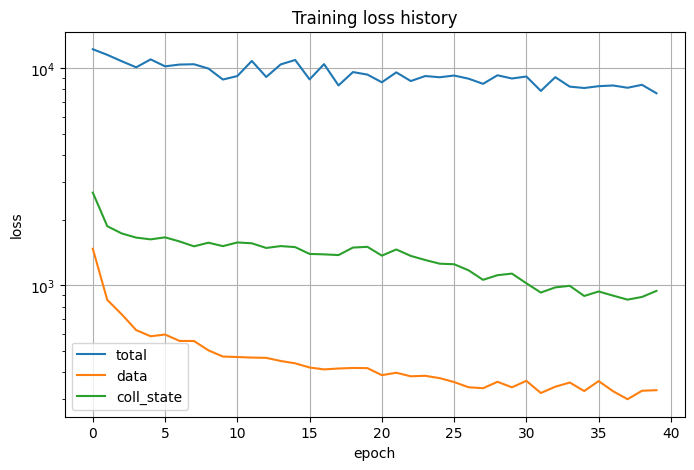

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

LOSS_CSV = "/content/drive/MyDrive/AI_EMUL2/training_runs/resunet_b96_big50_t8_energyex_uvgrad_momrel_lr5e5/loss_history.csv"

df = pd.read_csv(LOSS_CSV)
display(df.tail())

plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_total"], label="total")
plt.plot(df["epoch"], df["train_data"], label="data")
plt.plot(df["epoch"], df["train_coll_state"], label="coll_state")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Training loss history")
plt.show()

,epoch,train_total,train_data,train_coll_state,train_coll_tend,train_cont,train_mom,train_geo,train_smooth,train_uv_mag,train_ke,train_energy_tend
35,35,8283.155425,362.651876,938.426597,0.005758,0.001323,1.475301e-07,126.866690,7.159779e-17,0.050730,0.124970,156500.978824
36,36,8343.870859,325.752271,897.930145,0.005674,0.001505,1.540789e-07,122.929506,6.690741e-17,0.049156,0.113620,158535.482387
37,37,8146.435263,299.248338,860.647694,0.005677,0.001585,1.678008e-07,123.482148,6.377794e-17,0.049378,0.116415,155191.408798
38,38,8404.241933,327.413091,885.527737,0.005507,0.001813,1.479899e-07,126.721664,6.781409e-17,0.050669,0.126888,159732.942308
39,39,7684.138407,329.337890,944.347327,0.005454,0.001860,1.489815e-07,129.462824,7.269727e-17,0.051769,0.135349,145173.999120


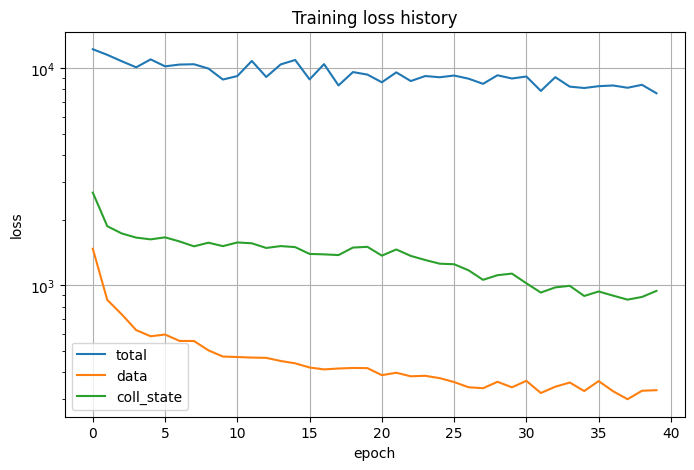

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

LOSS_CSV = "/content/drive/MyDrive/AI_EMUL2/training_runs/resunet_b96_big50_t8_energyex_uvgrad_momrel_lr5e5/loss_history.csv"



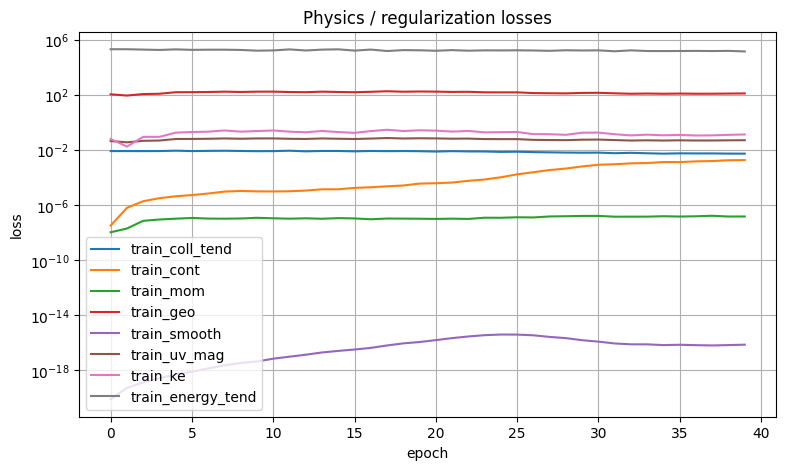

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

LOSS_CSV = "/content/drive/MyDrive/AI_EMUL2/training_runs/resunet_b96_big50_t8_energyex_uvgrad_momrel_lr5e5/loss_history.csv"

cols = [c for c in df.columns if c not in ["epoch", "train_total", "train_data", "train_coll_state"]]

plt.figure(figsize=(9,5))
for c in cols:
    plt.plot(df["epoch"], df[c], label=c)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Physics / regularization losses")
plt.show()